# **Data Pre-Processing**

In [ ]:
import pandas as pd
df = pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape # Show the dimensiion of dataframe

(541909, 8)

In [4]:
# Find data types of each column
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [5]:
#Check dataframe for missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# Calculate the percentage of missing values
null_percentage = df.isnull().sum() / len(df) * 100

# Show missing values percentage
print(null_percentage)


InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [7]:
# Drop missing Customer IDs and Description
df.dropna(subset=["CustomerID", "Description"], inplace=True)

In [8]:
# Check the demension of datframe after null removals
df.shape

(406829, 8)

In [9]:
# Convert data types in to the proper types
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C", na=False)]

In [10]:
# Remove negative or zero values in Quantity and UnitPrice
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

## **Create RFM Dataframe**


The following block of code calculates three key metrics (Recency, Frequency, and Monetary) for customer segmentation in the Online Retail dataset.

RFM analysis is used to group customers based on their purchase behavior. The three metrics represent:

Recency: How recently a customer made a purchase.

Frequency: How often a customer makes purchases.

Monetary : How much a customer spends.

Recency: Finds the latest purchase date for each customer.Calculates how many days have passed since their last purchase.

Frequency:Counts the number of unique transactions each customer has made.

Monetary: Computes the total spending per customer by multiplying Quantity * UnitPrice and summing the values.


This would help us to identify loyal customers, high spenders, and inactive users.also, it can be used to group customers into categories. We can use the scores to create personalized marketing desicions.

In [11]:
df = df.copy()

# Compute the latest transaction date in the dataset
latest_date = df["InvoiceDate"].max()

# Create "TotalPrice" column manually using .loc to avoid warning
df.loc[:, "TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Compute RFM metrics for each customer
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (latest_date - x.max()).days),  # Days since last purchase
    Frequency=("InvoiceNo", "nunique"),  # Count of unique transactions
    Monetary=("TotalPrice", "sum")  # Total spending amount
).reset_index()  # Reset index

# Display the first five rows
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [12]:
import pandas as pd


# Function to remove outliers using IQR
def detect_outliers(df, features):
    cleaned_df = df.copy()
    for col in features:
        # Calculate Q1 and Q3
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out outliers
        rfm_clean = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]

    return rfm_clean

# List of RFM features to clean
rfm_features = ['Recency', 'Frequency', 'Monetary']

# Remove outliers
rfmm = detect_outliers(rfm, rfm_features)
# Print results
print(f"\nOriginal dataset size: {rfm.shape[0]}")
print(f"Cleaned dataset size: {rfmm.shape[0]}")



Original dataset size: 4338
Cleaned dataset size: 3911


**Implementing Initial Cutomer Segmentation Score**

Each metric is scored on a scale. These individual scores are then combined to create an overall RFM score, which helps categorize customers into meaningful segments

In [13]:
# Compute R, F, M ranks
rfmm['R_rank'] = rfmm['Recency'].rank(ascending=False)  # Lower Recency = better
rfmm['F_rank'] = rfmm['Frequency'].rank(ascending=True)  # Higher Frequency = better
rfmm['M_rank'] = rfmm['Monetary'].rank(ascending=True)   # Higher Monetary = better

# Normalize the ranks from scale to 0-100
rfmm['R_rank_norm'] = (rfmm['R_rank'] / rfmm['R_rank'].max()) * 100
rfmm['F_rank_norm'] = (rfmm['F_rank'] / rfmm['F_rank'].max()) * 100
rfmm['M_rank_norm'] = (rfmm['M_rank'] / rfmm['M_rank'].max()) * 100

# Drop the original rank columns if no longer needed
rfmm.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)

# Display the first few rows
rfmm.head()


,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
2,12348.0,74,4,1797.24,41.770686,76.527742,85.221171
3,12349.0,18,1,1757.55,78.239609,19.010483,84.505242
4,12350.0,309,1,334.40,5.880839,19.010483,31.424188
5,12352.0,35,8,2506.04,62.990606,94.899003,92.994119
6,12353.0,203,1,89.00,18.556170,19.010483,2.965993


In [14]:
# Weighted RFM score calculation
rfmm['RFM_Score'] = (
    0.15 * rfmm['R_rank_norm'] +
    0.28 * rfmm['F_rank_norm'] +
    0.57 * rfmm['M_rank_norm']
)

# # Scale RFM score to a smaller range
rfmm['RFM_Score'] *= 0.05

# Round values to 2 decimals
rfmm = rfmm.round(2)

# Show top 10 customers by name and RFM score
rfmm[['CustomerID', 'RFM_Score']].head(10)


,CustomerID,RFM_Score
2,12348.0,3.81
3,12349.0,3.26
4,12350.0,1.21
5,12352.0,4.45
6,12353.0,0.49
7,12354.0,2.41
8,12355.0,1.60
9,12356.0,4.20
11,12358.0,3.51
13,12360.0,4.01


In [16]:
import numpy as np

# Segment customers based on RFM score thresholds
rfmm["Customer_segment"] = np.where(
    rfmm['RFM_Score'] > 4.5, "Top Customers",
    np.where(
        rfmm['RFM_Score'] > 4, "High Value Customers",
        np.where(
            rfmm['RFM_Score'] > 3, "Medium Value Customers",
            np.where(
                rfmm['RFM_Score'] > 1.6, "Low Value Customers",
                "Lost Customers"
            )
        )
    )
)

# Display customer segmentation results
rfmm[['CustomerID', 'RFM_Score', 'Customer_segment']].head(20)


,CustomerID,RFM_Score,Customer_segment
2,12348.0,3.81,Medium Value Customers
3,12349.0,3.26,Medium Value Customers
4,12350.0,1.21,Lost Customers
5,12352.0,4.45,High Value Customers
6,12353.0,0.49,Lost Customers
7,12354.0,2.41,Low Value Customers
8,12355.0,1.60,Lost Customers
9,12356.0,4.20,High Value Customers
11,12358.0,3.51,Medium Value Customers
13,12360.0,4.01,High Value Customers


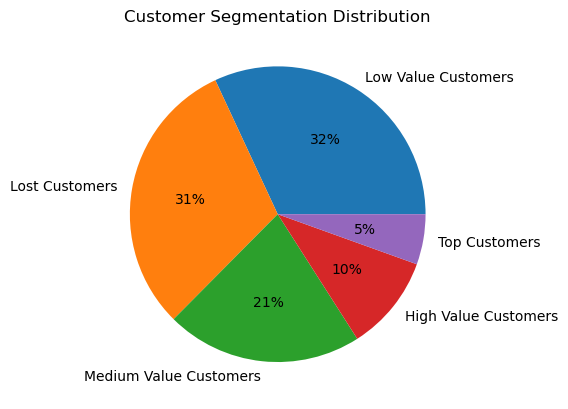

In [17]:
import matplotlib.pyplot as plt

# Pie chart of customer segments
plt.pie(
    rfmm['Customer_segment'].value_counts(),
    labels=rfmm['Customer_segment'].value_counts().index,
    autopct='%.0f%%'
)
plt.title("Customer Segmentation Distribution")
plt.show()


In [18]:
# Turn back dataset to 3 features of RFM
data = rfmm[['Recency', 'Frequency', 'Monetary']]
data.head()

,Recency,Frequency,Monetary
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40
5,35,8,2506.04
6,203,1,89.00


**Plot To Figure Out The Data Distribution**

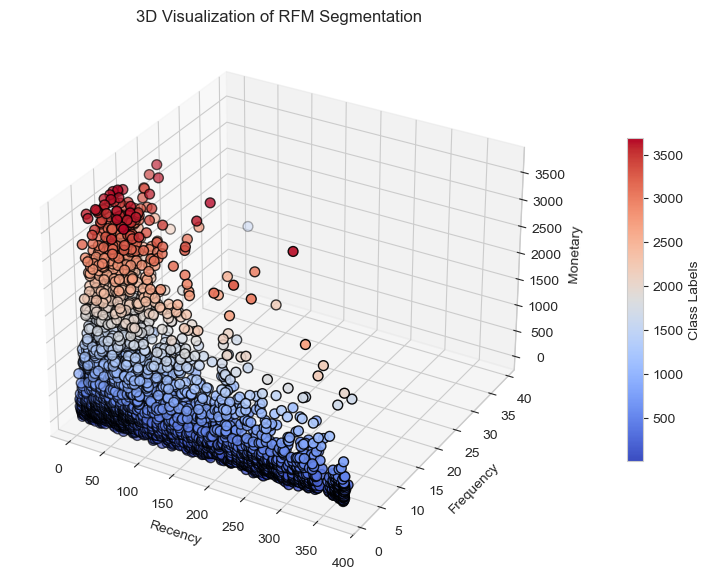

In [20]:
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Set the style
sns.set_style("whitegrid")

# Create the 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
scatter= ax.scatter(data["Recency"], data["Frequency"], data["Monetary"],
           c=rfmm["Monetary"], cmap="coolwarm", s=50, edgecolor='k')

# Labels and title
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("3D Visualization of RFM Segmentation")

# Add color bar to indicate classes
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Class Labels")

# Show the plot
plt.show()


**Dimension Reduction Usng PCA**

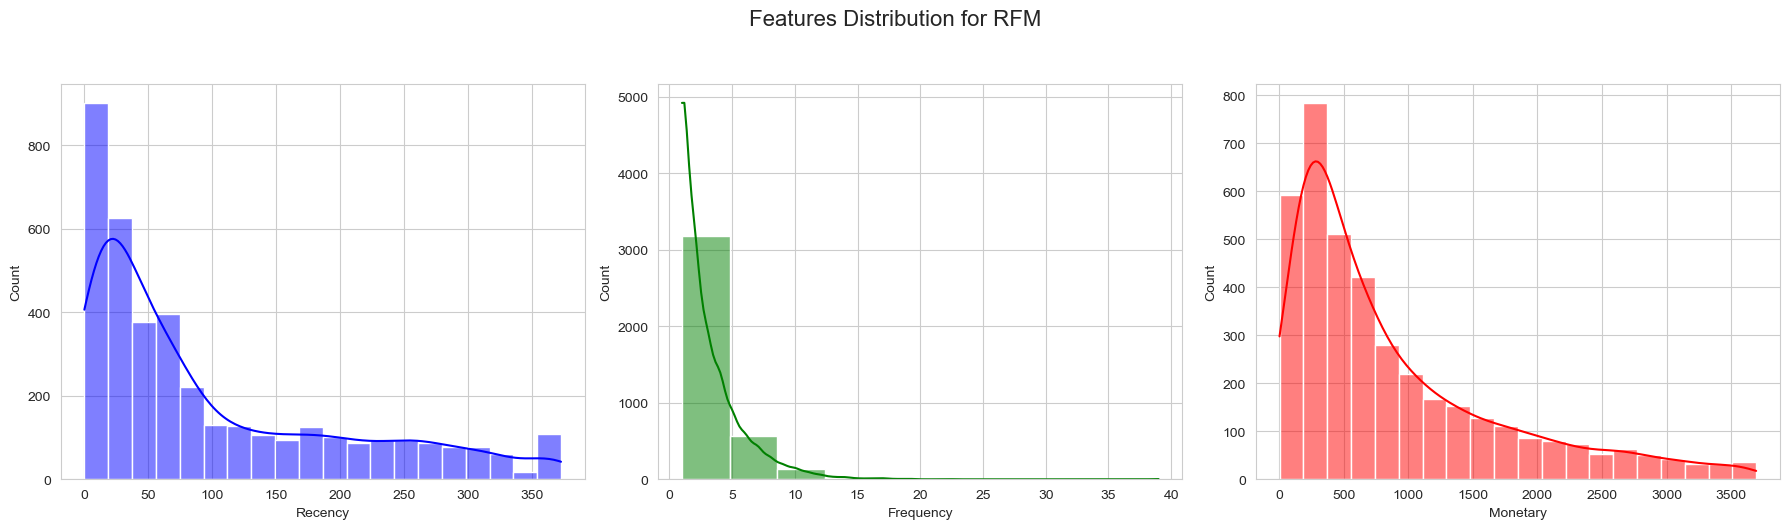

In [21]:
# style of the graph
sns.set_style("whitegrid")

# Subplots for each RFM feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Recency distribution
sns.histplot(data["Recency"], bins=20, kde=True, ax=axes[0], color="blue")

# Plot Frequency distribution
sns.histplot(data["Frequency"], bins=10, kde=True, ax=axes[1], color="green")

# Plot Monetary distribution
sns.histplot(data["Monetary"], bins=20, kde=True, ax=axes[2], color="red")

# Add main title to the figure
fig.suptitle("Features Distribution for RFM", fontsize=16, y=1.05)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


**Using Elbow Method To find The Optimal Number Of Clusters**

The results represent the best number of components that will be used in Kmeans clustering algorithm.

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Initialize lists to store WCSS and Silhouette Scores
wcss = []
silhouette_scores = []

# Define the range of cluster numbers to test
K_nums = range(3, 11)

# Iterate over different values of k to evaluate clustering performance
for k in K_nums:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)

    wcss.append(kmeans.inertia_)

    silhouette_avg = silhouette_score(data, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)



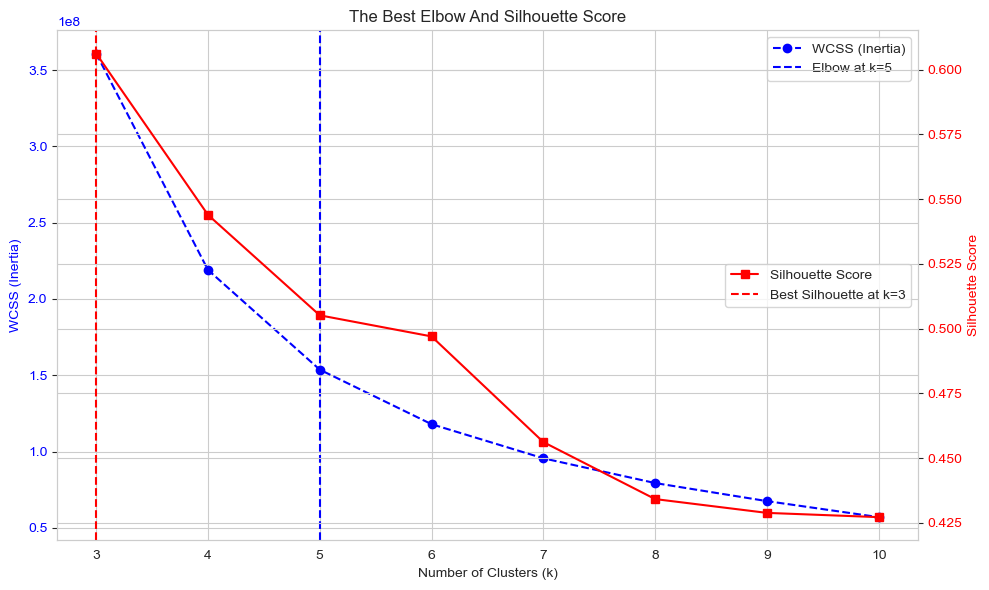

In [28]:
from kneed import KneeLocator

# Find the best elbow point
kneedle = KneeLocator(K_nums, wcss, curve='convex', direction='decreasing')
elbow_score = kneedle.elbow

# Find the best silhouette score
bestScore= K_nums[silhouette_scores.index(max(silhouette_scores))]

# Plot both in one graph
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot WCSS
ax1.plot(K_nums, wcss, 'bo--', label='WCSS (Inertia)')
ax1.axvline(elbow_score, color='blue', linestyle='--', label=f'Elbow at k={elbow_score}')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot Silhouette Score
ax2 = ax1.twinx()
ax2.plot(K_nums, silhouette_scores, 'rs-', label='Silhouette Score')
ax2.axvline(bestScore, color='red', linestyle='--', label=f'Best Silhouette at k={bestScore}')
ax2.set_ylabel('Silhouette Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Titles and Legends
plt.title('The Best Elbow And Silhouette Score')
ax1.legend(loc='upper right')
ax2.legend(loc='center right')
plt.tight_layout()
plt.show()



**Optimal Number of Clusters for GMM**

The following method determine the optimal number of clusters for segmenting RFM data using a Gaussian Mixture Model. It iterates over a range of cluster counts from 3 to 10, fits a GMM for each specified number of clusters on the RFM data , and calculates the Bayesian Information Criterion (BIC) for each model. The BIC score balances the model fit against its complexity. By comparing these BIC scores, the model with the lowest score can be identified as the best compromise between accuracy and simplicity, thereby guiding the selection of the optimal number of clusters for effective customer segmentation.

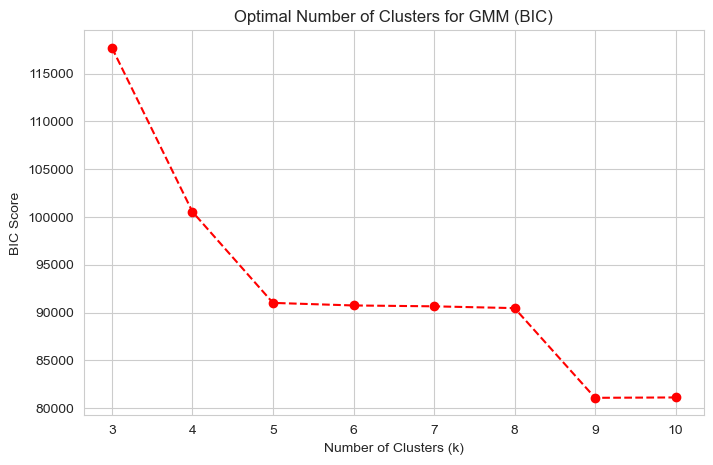

In [29]:
from sklearn.mixture import GaussianMixture

bic_scores = []  # Initialize an empty list to store BIC scores

for k in range(3, 11):  # Iterate over different numbers of clusters (from 3 to 10)
    gmm = GaussianMixture(n_components=k, random_state=42)  # Initialize Gaussian Mixture Model with k clusters
    gmm.fit(data)  # Fit the model to the RFM data
    bic_scores.append(gmm.bic(data))  # Compute and store the Bayesian Information Criterion (BIC) score


# Plot BIC scores
plt.figure(figsize=(8, 5))
plt.plot(range(3, 11), bic_scores, marker='o', linestyle='--', color='r')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("BIC Score")
plt.title("Optimal Number of Clusters for GMM (BIC)")
plt.show()


In [30]:
from sklearn.cluster import KMeans

# Clustering Algorithms (Only KMeans and GMM)
clustering_algorithms = {
    "KMeans": KMeans(n_clusters=5, random_state=42),
    "Gaussian Mixture Model": GaussianMixture(n_components=5, random_state=42)
}


In [31]:
# Store cluster labels and validation scores
cluster_data = {}
validation_scores = {}

# Fit models and get labels
for name, algorithm in clustering_algorithms.items():
    if name == "Gaussian Mixture Model":
        # For GMM use .fit and then .predict
        algorithm.fit(data)
        labels = algorithm.predict(data)
    else:
        # For KMeans or other sklearn models with fit_predict
        labels = algorithm.fit_predict(data)

    cluster_data[name] = labels

# Display the number of clusters found by each algorithm
for name, labels in cluster_data.items():
    unique_labels = set(labels)
    print(f"{name} - Unique Clusters Found: {len(unique_labels)}")


KMeans - Unique Clusters Found: 5
Gaussian Mixture Model - Unique Clusters Found: 5


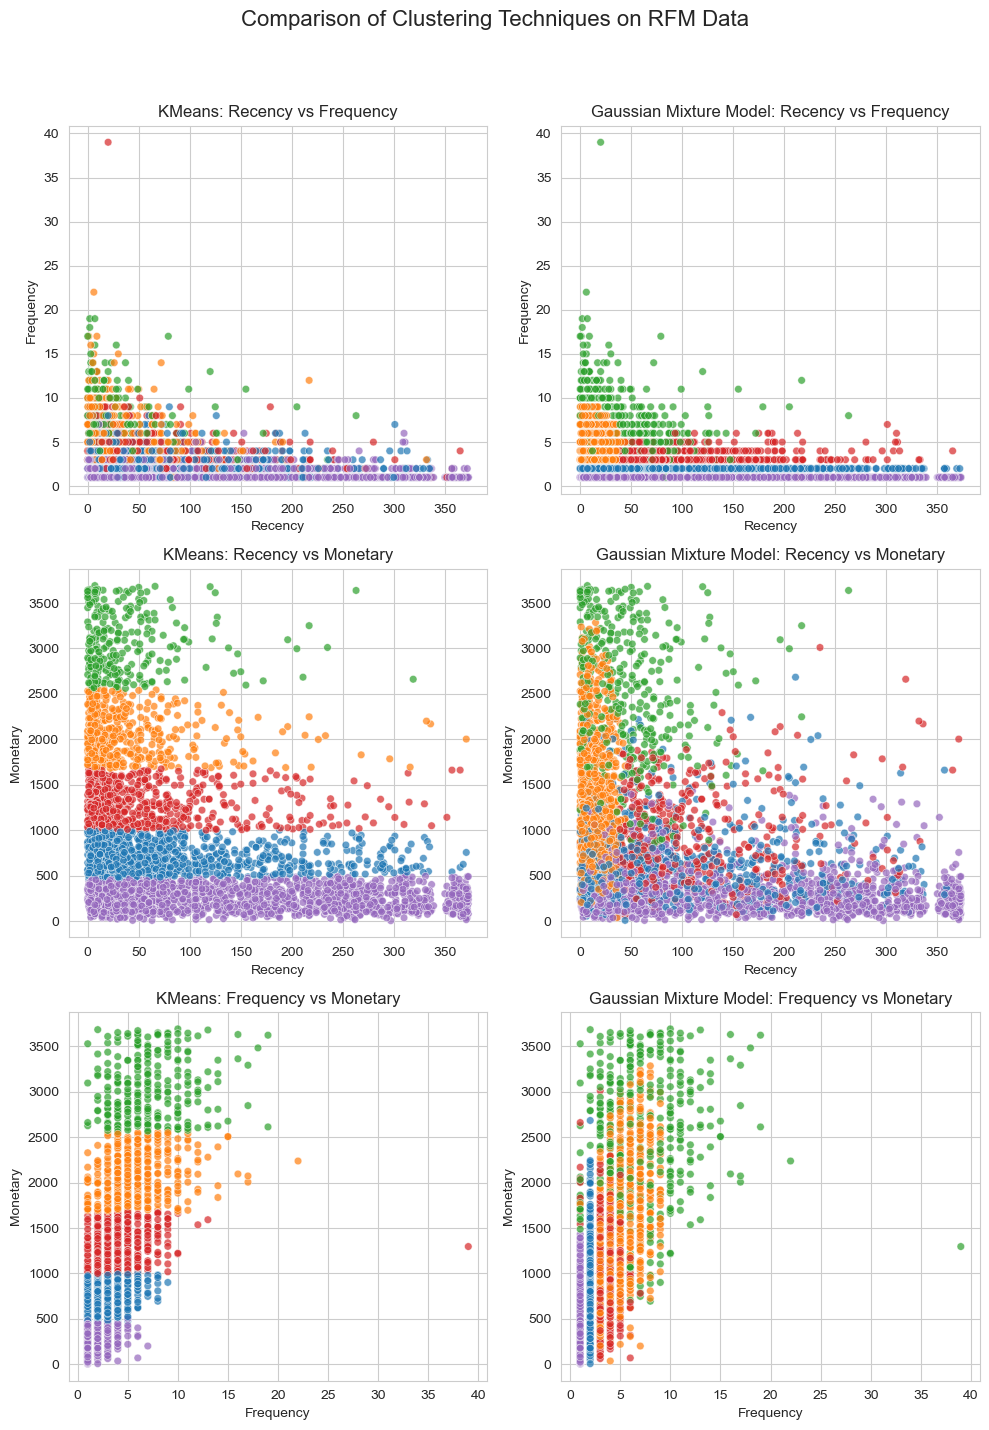

In [32]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
import seaborn as sns


for name, labels in cluster_data.items():

    # Compute clustering validation metrics only if there is more than one cluster
    if len(set(labels)) > 1:  # Silhouette Score requires at least 2 clusters
        silhouette = silhouette_score(data, labels)
    else:
        silhouette = -1  # Assign -1 when only one cluster exists to avoid errors

    # Compute Davies-Bouldin Index (lower is better)
    db_index = davies_bouldin_score(data, labels)

    # Compute Calinski-Harabasz Index (higher is better)
    ch_index = calinski_harabasz_score(data, labels)

    # Store validation scores in a dictionary
    validation_scores[name] = {
        "Silhouette Score": silhouette,
        "Davies-Bouldin Index": db_index,
        "Calinski-Harabasz Index": ch_index
    }

# Get the number of clustering methods used
num_clusters = len(cluster_data)

# Create subplots with 3 rows (for feature pairs) and num_clusters columns
fig, axes = plt.subplots(3, num_clusters, figsize=(5 * num_clusters, 15))
fig.suptitle("Comparison of Clustering Techniques on RFM Data", fontsize=16)

# If only one clustering method exists, make sure axes is 2D
if num_clusters == 1:
    axes = np.expand_dims(axes, axis=1)

# Iterate through the clustering results and visualize the clusters
for i, (name, labels) in enumerate(cluster_data.items()):
    unique_labels = len(set(labels))  # Get number of unique clusters
    palette = sns.color_palette("tab10", n_colors=unique_labels)  # Define color palette

    for j in range(3):
        # set features to plot based on j
        if j == 0:
            x = data["Recency"]
            xlabel = "Recency"

            y = data["Frequency"]
            ylabel = "Frequency"

        elif j == 1:
            x = data["Recency"]
            xlabel = "Recency"

            y = data["Monetary"]
            ylabel = "Monetary"

        else:
            x = data["Frequency"]
            xlabel = "Frequency"

            y = data["Monetary"]
            ylabel = "Monetary"

        # Scatter plot for visualizing clustering
        sns.scatterplot(
            x=x,
            y=y,
            hue=labels,  # Color clusters by labels
            palette=palette,  # Use color palette based on unique labels
            alpha=0.7,  # Set transparency
            s=30,  # Set point size
            ax=axes[j, i]  # Assign plot to the respective subplot
        )

        # Set plot title and axis labels
        axes[j, i].set_title(f"{name}: {xlabel} vs {ylabel}")
        axes[j, i].set_xlabel(xlabel)
        axes[j, i].set_ylabel(ylabel)

        # Remove legends from each subplot to avoid redundancy
        axes[j, i].legend([], frameon=False)

# Adjust layout to prevent overlapping labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Display the plots
plt.show()


In [36]:
# Convert validation scores to DataFrame
validation_df = pd.DataFrame(validation_scores).T


In [37]:
validation_df

,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
KMeans,0.506280,0.592002,16331.742608
Gaussian Mixture Model,0.038184,1.905984,1842.003003
